In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

In [2]:
#Step 1 - load the data
DATA = Path("../results")

emt_scores = pd.read_csv(DATA/"emt_scored_samples.tsv", sep="\t", index_col=0)
survival_table = pd.read_csv(DATA/"survival_table/tcga_cesc_survival.tsv", sep="\t", index_col=0)

print("EMT scores:", emt_scores.shape)
print("Survival table:", survival_table.shape)

EMT scores: (304, 1)
Survival table: (304, 2)


In [3]:
type(emt_scores)
emt_scores.head()
#emt_scores.describe

,EMT_score
5c8c8a6e-40d4-4f82-ac3d-90cfdee15c0a,0.985496
d9096909-1439-462d-b69c-cad1bf4f420c,-0.172502
29c17355-d646-48da-9e54-7b6dd85dd610,1.703241
29bcba51-2580-473d-9cf7-bedbd0dbad1b,0.521705
ad97b334-e034-4d33-a4d5-48c32d5d521c,0.429816


In [4]:
survival_table.head()

,time_days,event
5c8c8a6e-40d4-4f82-ac3d-90cfdee15c0a,1263.0,0
d9096909-1439-462d-b69c-cad1bf4f420c,940.0,0
29c17355-d646-48da-9e54-7b6dd85dd610,954.0,0
29bcba51-2580-473d-9cf7-bedbd0dbad1b,442.0,1
ad97b334-e034-4d33-a4d5-48c32d5d521c,2859.0,1


In [5]:
survival_table.columns

Index(['time_days', 'event'], dtype='object')

In [6]:
survival_table.shape

(304, 2)

In [7]:
#Step 2 - verify that time is numeric (time > 0) and event is 0/1
survival_table[["time_days", "event"]].describe()
#survival_table["event"].value_counts()

,time_days,event
count,304.000000,304.000000
mean,1019.378289,0.233553
std,1134.360304,0.423788
min,0.000000,0.000000
25%,353.750000,0.000000
50%,637.000000,0.000000
75%,1245.250000,0.000000
max,6408.000000,1.000000


In [8]:
(survival_table["time_days"] == 0).sum()

np.int64(13)

In [9]:
survival_table.loc[survival_table["time_days"] == 0, "event"].value_counts()

event
0    13
Name: count, dtype: int64

In [10]:
#Step 3 - merge data
common = emt_scores.index.intersection(survival_table.index)
emt_scores_2 = emt_scores.loc[common]
survival_table_2 = survival_table.loc[common]

df = survival_table_2[["time_days", "event"]].copy()

assert "EMT_score" in emt_scores_2.columns
assert df.index.equals(emt_scores_2.index)


df["EMT"] = emt_scores_2["EMT_score"]

In [11]:
df.head()

,time_days,event,EMT
5c8c8a6e-40d4-4f82-ac3d-90cfdee15c0a,1263.0,0,0.985496
d9096909-1439-462d-b69c-cad1bf4f420c,940.0,0,-0.172502
29c17355-d646-48da-9e54-7b6dd85dd610,954.0,0,1.703241
29bcba51-2580-473d-9cf7-bedbd0dbad1b,442.0,1,0.521705
ad97b334-e034-4d33-a4d5-48c32d5d521c,2859.0,1,0.429816


In [12]:
(df["time_days"] == 0).sum()

np.int64(13)

In [13]:
#Step 4 - drop the cases where time_days == 0
df = df[df["time_days"] > 0]
(df["time_days"] == 0).sum()

np.int64(0)

In [14]:
df["time_days"].describe()

count     291.000000
mean     1064.917526
std      1138.329251
min         2.000000
25%       412.000000
50%       699.000000
75%      1332.500000
max      6408.000000
Name: time_days, dtype: float64

In [15]:
df["event"].value_counts()

event
0    220
1     71
Name: count, dtype: int64

In [16]:
#Step 5 - check if indexes are unique
assert df.index.is_unique

In [17]:
df.head()

,time_days,event,EMT
5c8c8a6e-40d4-4f82-ac3d-90cfdee15c0a,1263.0,0,0.985496
d9096909-1439-462d-b69c-cad1bf4f420c,940.0,0,-0.172502
29c17355-d646-48da-9e54-7b6dd85dd610,954.0,0,1.703241
29bcba51-2580-473d-9cf7-bedbd0dbad1b,442.0,1,0.521705
ad97b334-e034-4d33-a4d5-48c32d5d521c,2859.0,1,0.429816


In [18]:
#Step 6 - fitting the Cox proportional hazards model

from lifelines import CoxPHFitter

In [19]:
df.dtypes

time_days    float64
event          int64
EMT          float64
dtype: object

In [20]:
df.isna().sum()

time_days    0
event        0
EMT          0
dtype: int64

In [21]:
cph = CoxPHFitter()

cph.fit(df, duration_col="time_days", event_col="event")
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 291 total observations, 220 right-censored observations>
             duration col = 'time_days'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 291
number of events observed = 71
   partial log-likelihood = -342.00
         time fit was run = 2026-05-22 09:05:37 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
EMT        0.28      1.32      0.11            0.05            0.50                1.06                1.66

           cmp to    z    p  -log2(p)
covariate                            
EMT          0.00 2.44 0.01      6.07
---
Concordance = 0.60
Partial AIC = 686.01
log-likelihood ratio test = 5.75 on 1 df
-log2(p) of ll-ratio test = 5.92

In [22]:
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 291 total observations, 220 right-censored observations>
             duration col = 'time_days'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 291
number of events observed = 71
   partial log-likelihood = -342.00
         time fit was run = 2026-05-22 09:05:37 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
EMT        0.28      1.32      0.11            0.05            0.50                1.06                1.66

           cmp to    z    p  -log2(p)
covariate                            
EMT          0.00 2.44 0.01      6.07
---
Concordance = 0.60
Partial AIC = 686.01
log-likelihood ratio test = 5.75 on 1 df
-log2(p) of ll-ratio test = 5.92

In [23]:
#Step 7 - save the dataframe used for Cox
OUT = Path("../results/cox")
OUT.mkdir(exist_ok=True)

df.to_csv(OUT/"cox_input_emt_only.tsv", sep="\t")

In [24]:
#Step 8 - save model summary and metadata
cph.summary.to_csv(OUT/"cox_emt_summary.tsv", sep="\t")

In [25]:
with open(OUT / "cox_emt_metadata.txt", "w") as f:
    f.write(f"Model: Cox proportional hazards\n")
    f.write(f"Predictors: EMT (z-scored)\n")
    f.write(f"n_samples: {df.shape[0]}\n")
    f.write(f"n_events: {df['event'].sum()}\n")
    f.write(f"Baseline estimation: {cph.baseline_estimation_method}\n")



   Bootstrapping lowess lines. May take a moment...

Proportional hazard assumption looks okay.


[[<Axes: xlabel='rank-transformed time\n(p=0.8477)'>,
  <Axes: xlabel='km-transformed time\n(p=0.9454)'>]]

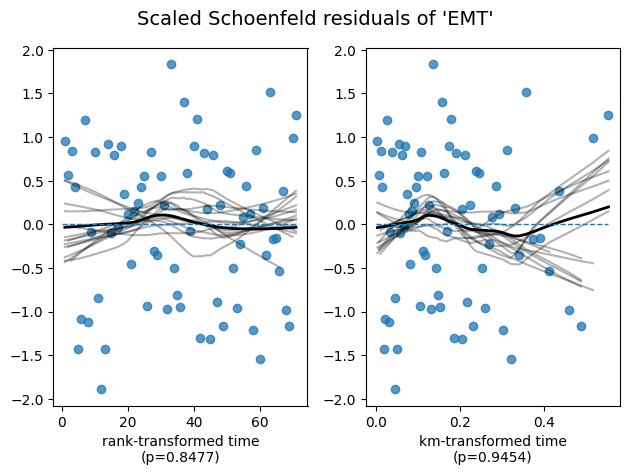

In [26]:
#Step 9 - cox model dianostics
cph.check_assumptions(
    df,
    p_value_threshold=0.05,
    show_plots=True
)


In [27]:
with open(OUT / "cox_emt_metadata.txt", "a") as f:
    f.write("PH assumption checked using Schoenfeld residuals\n")


In [28]:
#Step 10 - Kaplan-Meier plot with linear predictors

import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test

df = df.copy()

In [29]:
#linear predictor (log partial hazard)
df["risk_lp"] = cph.predict_log_partial_hazard(df)

In [30]:
df["risk_tertile"] = pd.qcut(df["risk_lp"], q=3, labels=["Low risk", "Mid risk", "High risk"])

In [31]:
df["risk_tertile"] = pd.Categorical(df["risk_tertile"], categories=["Low risk", "Mid risk", "High risk"], ordered=True)


In [32]:
summary = df.groupby("risk_tertile").agg(
    n=("risk_lp", "size"),
    events=("event", "sum"),
    median_time=("time_days", "median"),
)
print(summary)

               n  events  median_time
risk_tertile                         
Low risk      97      20        788.0
Mid risk      97      16        725.0
High risk     97      35        636.0


/tmp/ipykernel_8984/2712206791.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby("risk_tertile").agg(


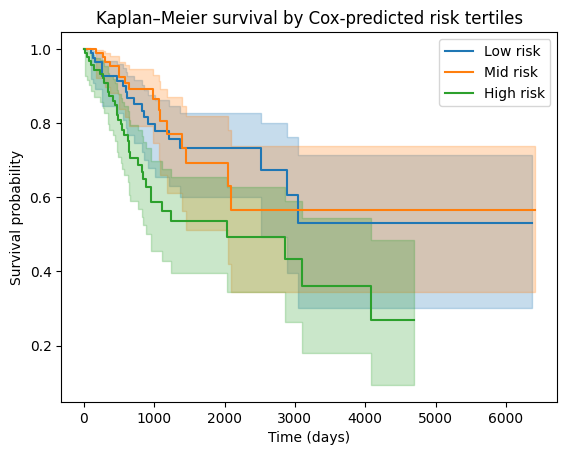

In [33]:
kmf = KaplanMeierFitter()

plt.figure()
for group in df["risk_tertile"].cat.categories:
    g = df[df["risk_tertile"] == group]
    kmf.fit(durations=g["time_days"], event_observed=g["event"], label=str(group))
    kmf.plot_survival_function()

plt.xlabel("Time (days)")
plt.ylabel("Survival probability")
plt.title("Kaplan–Meier survival by Cox-predicted risk tertiles")
plt.show()

In [34]:
lr = multivariate_logrank_test(
    df["time_days"],
    df["risk_tertile"],
    df["event"]
)
print("Multigroup log-rank p =", lr.p_value)

Multigroup log-rank p = 0.0028321419496313916


In [35]:
OUT_2 = Path("../results/figures_and_log_rank")
OUT_2.mkdir(exist_ok=True)

In [36]:
with open(OUT_2 / "multigroup_log_rank.txt", "w") as f:
    f.write(f"Multigroup log-rank test p-value: {lr.p_value}")


In [37]:
#Step 11 - bootstrap internal validation
df_boot = df[["time_days", "event", "EMT"]].copy()

In [38]:
c_apparent = cph.score(df_boot, scoring_method="concordance_index")
print("Apparent C-index:", float(c_apparent))

Apparent C-index: 0.6022398843930635


In [ ]:
B = 1000
seed = 123
rng = np.random.default_rng(seed)

optimisms = []
boot_train_c = []
boot_test_c = []

n = df_boot.shape[0]

for b in range(B):
    # draw bootstrap indices with replacement
    idx = rng.integers(0, n, size=n)
    df_boot_2 = df_boot.iloc[idx].copy()

     # fit model on bootstrap sample
    cph_b = CoxPHFitter()
    cph_b.fit(df_boot_2, duration_col="time_days", event_col="event")

    # evaluate discrimination (C-index) on:
    #     bootstrap sample
    #     original full dataset
    c_train = cph_b.score(df_boot_2, scoring_method="concordance_index")
    c_test  = cph_b.score(df_boot,      scoring_method="concordance_index")

    boot_train_c.append(float(c_train))
    boot_test_c.append(float(c_test))
    optimisms.append(float(c_train - c_test))

# average optimism and correct the apparent performance
mean_optimism = float(np.mean(optimisms))
c_corrected = float(c_apparent - mean_optimism)

print("\nBootstrap results")
print("Mean optimism:", mean_optimism)
print("Optimism-corrected C-index:", c_corrected)



/home/annettestomakhin/Magistritöö/.venv/lib/python3.12/site-packages/lifelines/utils/__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")
/home/annettestomakhin/Magistritöö/.venv/lib/python3.12/site-packages/lifelines/utils/__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")
/home/annettestomakhin/Magistritöö/.venv/lib/python3.12/site-packages/lifelines/utils/__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")
/home/annettestomakhin/Magistritöö/.venv/lib/python3.12/site-packages/lifelines/utils/__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting


Bootstrap results
Mean optimism: 0.0026312979043899383
Optimism-corrected C-index: 0.5996085864886735


/home/annettestomakhin/Magistritöö/.venv/lib/python3.12/site-packages/lifelines/utils/__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")
/home/annettestomakhin/Magistritöö/.venv/lib/python3.12/site-packages/lifelines/utils/__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")
/home/annettestomakhin/Magistritöö/.venv/lib/python3.12/site-packages/lifelines/utils/__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")
/home/annettestomakhin/Magistritöö/.venv/lib/python3.12/site-packages/lifelines/utils/__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting